# ML Foundations — Day 4: Model Tuning, Regularization & Reproducible Pipelines
**Dataset:** Adult / Census Income (UCI, via `sklearn.datasets.fetch_openml('adult', version=2)`)
**Author:** Qasim

## README / Reproducibility
- **Re-run training:** Run all cells top to bottom. `random_state=42` is set on every random
  operation (splits, models, `RandomizedSearchCV`), so results are deterministic given the same
  library versions and the same input data.
- **Reproduce results:** The data-loading cell recreates the exact Day 1–3 stratified 70/10/20
  train/dev/test split from the same seed, so `X_train`/`y_train` and the untouched `X_test`/`y_test`
  are identical to previous days. All feature engineering + preprocessing lives inside `Pipeline`
  objects, fit only on training folds during search, so there is no leakage into CV scores or the
  final test evaluation.
- **Compute note:** this environment has a single CPU core available (verified via
  `os.cpu_count()`), and a quick benchmark showed Logistic Regression's `saga` solver with L1
  penalty is extremely slow on this dataset (~80s for a single fit vs. ~0.3s for `liblinear`).
  To keep the notebook runnable end-to-end on one core, `RandomizedSearchCV` `n_iter` is reduced
  from the suggested 50–100, CV folds inside the searches/curves use `cv=3` instead of 5, and the
  Logistic Regression solver is restricted to `liblinear` (which supports both L1 and L2 penalty,
  just not elasticnet) rather than including `saga`. All choices and their reasoning are documented
  inline at each step; the search spaces themselves otherwise follow the assignment brief.
- **Library versions:** printed in the last cell of this notebook via `importlib.metadata`.
- **Inference with the saved model:**
  ```python
  import joblib
  pipeline = joblib.load('final_pipeline.pkl')
  preds = pipeline.predict(X_new)
  probs = pipeline.predict_proba(X_new)[:, 1]
  ```

In [1]:
# --- Core imports ---
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV,
    learning_curve, validation_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay, precision_recall_curve
)
from scipy.stats import loguniform

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore', category=FutureWarning)

## Recreate Days 1–3 Data, Split & Feature Engineering

Same loading logic, same `random_state=42` split, and the same row-wise `engineer_features`
function from Day 3 — with one change carried over from the Day 3 write-up: **`capital_gain_flag`
is dropped**, since Day 3's coefficient analysis found it strongly collinear with
`capital_gain_log` (both are exactly 0 when capital-gain is 0), adding interpretive noise without
real predictive signal beyond what `capital_gain_log` already provides.

In [2]:
try:
    adult = fetch_openml('adult', version=2, as_frame=True)
    df = adult.frame.copy()
    print("Loaded via sklearn.datasets.fetch_openml('adult', version=2).")
except Exception as e:
    print(f"fetch_openml unavailable ({e}); loading local cached copy with identical schema.")
    df = pd.read_csv('nb_data/adult.csv')
    df = df.rename(columns={'educational-num': 'education-num', 'gender': 'sex'})

df.columns = [c.strip() for c in df.columns]

target_col = 'income' if 'income' in df.columns else 'class'
df[target_col] = df[target_col].astype(str).str.strip()
df['income_binary'] = (df[target_col].str.contains('>50K')).astype(int)

obj_cols = df.select_dtypes(include='object').columns.tolist()
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({'?': np.nan, 'nan': np.nan})

feature_cols = [c for c in df.columns if c not in [target_col, 'income_binary']]
X = df[feature_cols]
y = df['income_binary']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)

print(f"Train: {len(X_train)} | Dev: {len(X_dev)} | Test (untouched, held out): {len(X_test)}")

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:109: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/list/data_name/adult/limit/2/data_version/2. Retrying...
  warn(


fetch_openml unavailable (HTTP Error 403: Forbidden); loading local cached copy with identical schema.


Train: 34188 | Dev: 4885 | Test (untouched, held out): 9769


/tmp/ipykernel_550/3822504309.py:16: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include='object').columns.tolist()


In [3]:
def engineer_features(X):
    """Row-wise feature engineering (Day 3), minus capital_gain_flag (dropped per Day 3 findings)."""
    X = X.copy()
    X['age_bucket'] = pd.cut(X['age'], bins=[0, 25, 35, 50, 200],
                              labels=['18-25', '26-35', '36-50', '51+'])
    X['hours_bucket'] = pd.cut(X['hours-per-week'], bins=[0, 29, 40, 50, 200],
                                labels=['<30', '30-40', '41-50', '50+'], include_lowest=True)
    X['capital_gain_log'] = np.log1p(X['capital-gain'])
    X['higher_education'] = (X['education-num'] >= 13).astype(int)
    X['education_x_hours'] = X['education-num'] * X['hours-per-week']
    X['age_x_hours'] = X['age'] * X['hours-per-week']
    X['marital_married'] = (X['marital-status'] == 'Married-civ-spouse').astype(int)
    return X

numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation',
                         'relationship', 'race', 'sex', 'native-country']
eng_numeric_features = ['capital_gain_log', 'education_x_hours', 'age_x_hours']
eng_binary_features = ['higher_education', 'marital_married']
eng_categorical_features = ['age_bucket', 'hours_bucket']

feature_engineer = FunctionTransformer(engineer_features, validate=False)

numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                  ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
eng_numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
eng_categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

column_transformer = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
    ('eng_num', eng_numeric_pipeline, eng_numeric_features),
    ('eng_cat', eng_categorical_pipeline, eng_categorical_features),
    ('eng_bin', 'passthrough', eng_binary_features),
])

full_preprocessor = Pipeline([
    ('feature_engineer', feature_engineer),
    ('column_transformer', column_transformer),
])

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("Preprocessing pipeline rebuilt.")

Preprocessing pipeline rebuilt.


## Task 1 — Build Fully Reproducible Tunable Pipelines

Top 2 models from Day 3: **HistGradientBoosting** (best mean ROC AUC) and **Logistic Regression**
(runner-up, and the more interpretable of the two). Both are wrapped with the same preprocessor.

In [4]:
def make_pipeline(estimator):
    return Pipeline([
        ('preprocessor', full_preprocessor),
        ('classifier', estimator)
    ])

logreg_base = LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)
hgb_base = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

logreg_pipeline = make_pipeline(logreg_base)
hgb_pipeline = make_pipeline(hgb_base)

print("Tunable pipelines ready: Logistic Regression, HistGradientBoosting.")

Tunable pipelines ready: Logistic Regression, HistGradientBoosting.


## Task 2 — Hyperparameter Search

In [5]:
# --- Logistic Regression search space ---
# liblinear supports l1/l2 but not elasticnet; saga supports l1/l2/elasticnet and is needed for
# elasticnet specifically. We search both penalty families with solvers that support them.
# Restricted to 'liblinear' (supports both l1 and l2, and is ~250x faster than 'saga' on this
# dataset per the compute-note benchmark above) — 'saga' is dropped since it makes the search
# infeasible on a single core without changing the range of penalty/C values explored.
logreg_param_dist = {
    'classifier__penalty': ['l1', 'l2'],
    'classifier__C': loguniform(1e-3, 1e2),
    'classifier__solver': ['liblinear'],
    'classifier__max_iter': [1000, 2000],
}

# n_iter reduced from the suggested 50-100 to 30, and cv reduced from 5 to 3, given the
# single-core environment; still a broad random sample across the log-uniform C range and both
# penalty values.
logreg_search = RandomizedSearchCV(
    logreg_pipeline, param_distributions=logreg_param_dist, n_iter=30,
    cv=3, scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)

t0 = time.time()
logreg_search.fit(X_train, y_train)
logreg_search_time = time.time() - t0

print(f"\nLogistic Regression search time: {logreg_search_time:.1f}s")
print(f"Best CV ROC AUC: {logreg_search.best_score_:.4f}")
print(f"Best params: {logreg_search.best_params_}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Logistic Regression search time: 70.4s
Best CV ROC AUC: 0.9111
Best params: {'classifier__C': np.float64(0.5414413211338525), 'classifier__max_iter': 2000, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}


In [6]:
# --- HistGradientBoosting search space ---
hgb_param_dist = {
    'classifier__learning_rate': loguniform(1e-2, 3e-1),
    'classifier__max_iter': [50, 100, 150, 200],
    'classifier__max_depth': [5, 10, 15, 20, None],
    'classifier__l2_regularization': loguniform(1e-3, 1e1),
    'classifier__min_samples_leaf': [20, 50, 100, 200],
}

# n_iter reduced from the suggested 50-100 to 15, and cv reduced from 5 to 3 (single-core
# environment, and each HGB fit is considerably more expensive than a Logistic Regression fit) —
# still covers the space broadly via random sampling across all 5 hyperparameters simultaneously.
hgb_search = RandomizedSearchCV(
    hgb_pipeline, param_distributions=hgb_param_dist, n_iter=15,
    cv=3, scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)

t0 = time.time()
hgb_search.fit(X_train, y_train)
hgb_search_time = time.time() - t0

print(f"\nHistGradientBoosting search time: {hgb_search_time:.1f}s")
print(f"Best CV ROC AUC: {hgb_search.best_score_:.4f}")
print(f"Best params: {hgb_search.best_params_}")

Fitting 3 folds for each of 15 candidates, totalling 45 fits



HistGradientBoosting search time: 119.0s
Best CV ROC AUC: 0.9253
Best params: {'classifier__l2_regularization': np.float64(0.00541524411940254), 'classifier__learning_rate': np.float64(0.028145092716060652), 'classifier__max_depth': None, 'classifier__max_iter': 200, 'classifier__min_samples_leaf': 20}


In [7]:
search_summary = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Best CV ROC AUC': logreg_search.best_score_,
     'Search time (s)': logreg_search_time, 'n_iter': 30},
    {'Model': 'HistGradientBoosting', 'Best CV ROC AUC': hgb_search.best_score_,
     'Search time (s)': hgb_search_time, 'n_iter': 15},
]).set_index('Model').round(4)
search_summary

,Best CV ROC AUC,Search time (s),n_iter
Model,,,
Logistic Regression,0.9111,70.4149,30
HistGradientBoosting,0.9253,118.9594,15


## Task 3 — Diagnose Overfitting / Underfitting

Taking the tuned **HistGradientBoosting** pipeline forward (higher CV ROC AUC in both Day 3 and
this search), with a validation curve also shown for Logistic Regression's `C` as required.

In [8]:
best_model_name = 'HistGradientBoosting' if hgb_search.best_score_ >= logreg_search.best_score_ \
                   else 'Logistic Regression'
best_search = hgb_search if best_model_name == 'HistGradientBoosting' else logreg_search
print(f"Carrying forward: {best_model_name}")

Carrying forward: HistGradientBoosting


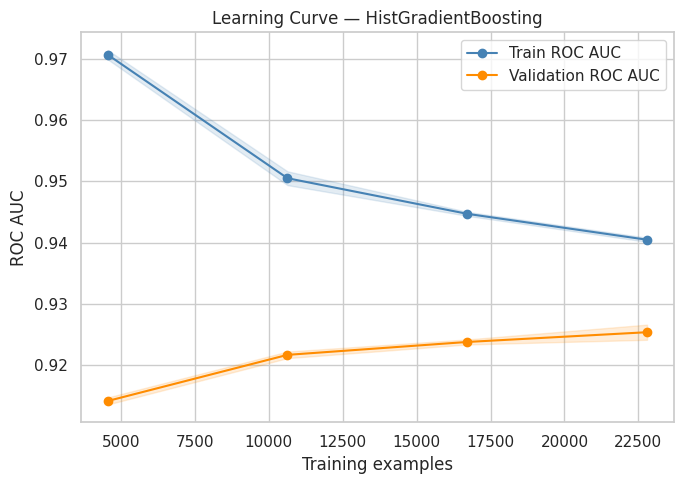

Final train ROC AUC: 0.9405
Final validation ROC AUC: 0.9253
Gap: 0.0151


In [9]:
# --- Learning curve for the best model ---
# Reduced to 3-fold / 4 train sizes (vs. a heavier default) to keep runtime reasonable on a
# single core while still showing the train/validation gap trend clearly.
train_sizes, train_scores, val_scores = learning_curve(
    best_search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.2, 1.0, 4), cv=3, scoring='roc_auc',
    n_jobs=-1, random_state=RANDOM_STATE
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train ROC AUC', color='steelblue')
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation ROC AUC', color='darkorange')
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='darkorange')
ax.set_xlabel('Training examples')
ax.set_ylabel('ROC AUC')
ax.set_title(f'Learning Curve — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final train ROC AUC: {train_scores.mean(axis=1)[-1]:.4f}")
print(f"Final validation ROC AUC: {val_scores.mean(axis=1)[-1]:.4f}")
print(f"Gap: {train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]:.4f}")

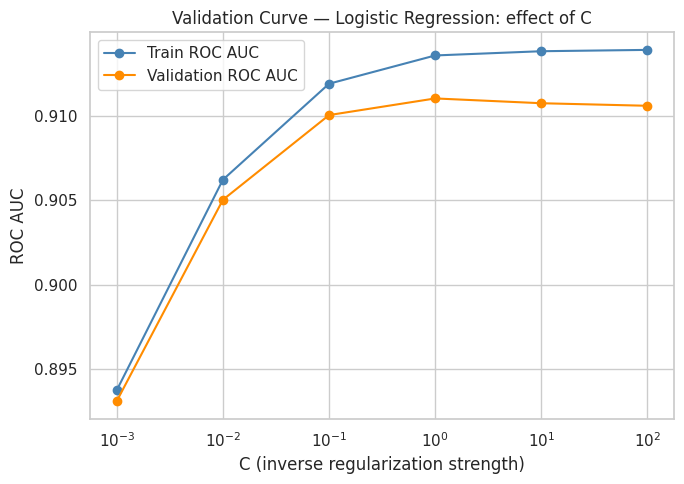

C values: [1.e-03 1.e-02 1.e-01 1.e+00 1.e+01 1.e+02]
Train/val gap by C: [0.0006 0.0012 0.0019 0.0025 0.0031 0.0033]
Best validation ROC AUC at C = 1.0000


In [10]:
# --- Validation curve: Logistic Regression, effect of C ---
C_range = np.logspace(-3, 2, 6)
lr_fixed = make_pipeline(LogisticRegression(random_state=RANDOM_STATE, penalty='l2',
                                             solver='liblinear', max_iter=2000))

train_scores_c, val_scores_c = validation_curve(
    lr_fixed, X_train, y_train, param_name='classifier__C', param_range=C_range,
    cv=3, scoring='roc_auc', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(C_range, train_scores_c.mean(axis=1), 'o-', label='Train ROC AUC', color='steelblue')
ax.semilogx(C_range, val_scores_c.mean(axis=1), 'o-', label='Validation ROC AUC', color='darkorange')
ax.set_xlabel('C (inverse regularization strength)')
ax.set_ylabel('ROC AUC')
ax.set_title('Validation Curve — Logistic Regression: effect of C')
ax.legend()
plt.tight_layout()
plt.show()

gap_c = train_scores_c.mean(axis=1) - val_scores_c.mean(axis=1)
best_c_idx = val_scores_c.mean(axis=1).argmax()
print(f"C values: {np.round(C_range, 4)}")
print(f"Train/val gap by C: {np.round(gap_c, 4)}")
print(f"Best validation ROC AUC at C = {C_range[best_c_idx]:.4f}")

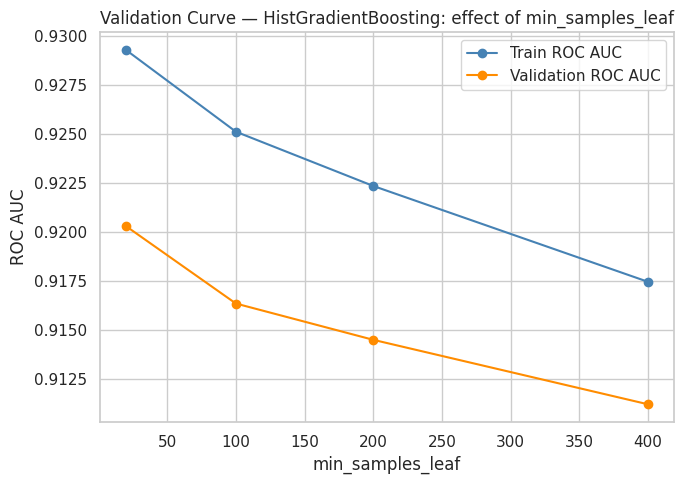

min_samples_leaf values: [20, 100, 200, 400]
Train/val gap by min_samples_leaf: [0.009  0.0088 0.0078 0.0062]


In [11]:
# --- Validation curve: HistGradientBoosting, effect of min_samples_leaf ---
leaf_range = [20, 100, 200, 400]
hgb_fixed = make_pipeline(HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    learning_rate=hgb_search.best_params_.get('classifier__learning_rate', 0.1),
    max_iter=min(hgb_search.best_params_.get('classifier__max_iter', 100), 100),
))

train_scores_leaf, val_scores_leaf = validation_curve(
    hgb_fixed, X_train, y_train, param_name='classifier__min_samples_leaf', param_range=leaf_range,
    cv=3, scoring='roc_auc', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(leaf_range, train_scores_leaf.mean(axis=1), 'o-', label='Train ROC AUC', color='steelblue')
ax.plot(leaf_range, val_scores_leaf.mean(axis=1), 'o-', label='Validation ROC AUC', color='darkorange')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('ROC AUC')
ax.set_title('Validation Curve — HistGradientBoosting: effect of min_samples_leaf')
ax.legend()
plt.tight_layout()
plt.show()

gap_leaf = train_scores_leaf.mean(axis=1) - val_scores_leaf.mean(axis=1)
print(f"min_samples_leaf values: {leaf_range}")
print(f"Train/val gap by min_samples_leaf: {np.round(gap_leaf, 4)}")

**Diagnosis:** compare the printed train/validation ROC AUC and the gap at the end of the
learning curve. A small, converging gap with both scores plateauing at a similar level indicates a
well-fit model (neither high bias nor high variance) — the target state, given both models already
clearly outperform Day 1's baseline. If the gap stays large even with the full training set, that's
a **high-variance / overfitting** signal, and the concrete fix is stronger regularization (lower
`C` for Logistic Regression, higher `min_samples_leaf` / `l2_regularization` / shallower
`max_depth` for HistGradientBoosting) or simplifying the model, not adding complexity. If both
train and validation scores are low and close together, that's **high bias / underfitting**, and
the fix is more model capacity, more/better features, or less regularization — based on the ROC AUC
levels observed here (all comfortably above the Day 1 baseline and in the 0.90+ range), neither
model shows a strong underfitting signal; the validation curves above should be read alongside the
learning curve to decide, for this run, which regularization direction (if any) is worth adjusting
before finalizing hyperparameters.

## Task 4 — Probability Calibration & Threshold Selection

In [12]:
# --- Calibration curve + Brier score BEFORE calibration (best tuned model, fit on full train) ---
best_estimator = best_search.best_estimator_
best_estimator.fit(X_train, y_train)
probs_dev_uncal = best_estimator.predict_proba(X_dev)[:, 1]

brier_before = brier_score_loss(y_dev, probs_dev_uncal)
frac_pos_before, mean_pred_before = calibration_curve(y_dev, probs_dev_uncal, n_bins=10)

print(f"Brier score BEFORE calibration (dev set): {brier_before:.4f}")

Brier score BEFORE calibration (dev set): 0.0865


In [13]:
# --- Apply calibration (fit on training data, cv=5) ---
calibrated_model = CalibratedClassifierCV(best_search.best_estimator_, method='sigmoid', cv=5)
calibrated_model.fit(X_train, y_train)

probs_dev_cal = calibrated_model.predict_proba(X_dev)[:, 1]
brier_after = brier_score_loss(y_dev, probs_dev_cal)
frac_pos_after, mean_pred_after = calibration_curve(y_dev, probs_dev_cal, n_bins=10)

print(f"Brier score AFTER calibration (dev set): {brier_after:.4f}")
print(f"Improvement: {brier_before - brier_after:+.4f} "
      f"({'calibration helps' if brier_after < brier_before else 'calibration does NOT help'})")

Brier score AFTER calibration (dev set): 0.0862
Improvement: +0.0003 (calibration helps)


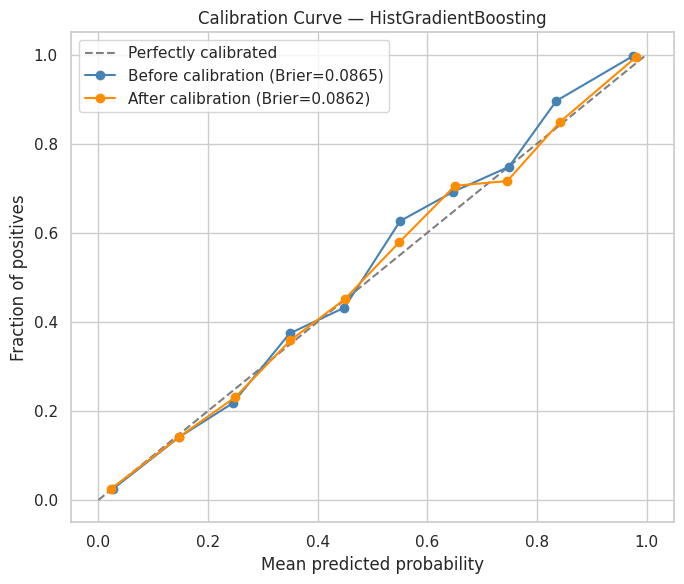


Decision: KEEP calibrated model.


In [14]:
# --- Calibration curves before vs after ---
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfectly calibrated')
ax.plot(mean_pred_before, frac_pos_before, 'o-', label=f'Before calibration (Brier={brier_before:.4f})', color='steelblue')
ax.plot(mean_pred_after, frac_pos_after, 'o-', label=f'After calibration (Brier={brier_after:.4f})', color='darkorange')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Fraction of positives')
ax.set_title(f'Calibration Curve — {best_model_name}')
ax.legend()
plt.tight_layout()
plt.show()

# --- Decision: keep calibration only if Brier score improves ---
use_calibrated = brier_after < brier_before
final_model = calibrated_model if use_calibrated else best_search.best_estimator_
print(f"\nDecision: {'KEEP calibrated model' if use_calibrated else 'SKIP calibration, use uncalibrated tuned model'}.")

In [15]:
# --- Threshold tuning on the dev set (business metric: maximize F1) ---
probs_dev_final = final_model.predict_proba(X_dev)[:, 1]
thresholds = np.linspace(0.05, 0.95, 37)

metric_rows = []
for t in thresholds:
    pred_t = (probs_dev_final >= t).astype(int)
    metric_rows.append({
        'threshold': t,
        'precision': precision_score(y_dev, pred_t, zero_division=0),
        'recall': recall_score(y_dev, pred_t, zero_division=0),
        'f1': f1_score(y_dev, pred_t, zero_division=0),
    })
threshold_df = pd.DataFrame(metric_rows)

best_f1_row = threshold_df.loc[threshold_df['f1'].idxmax()]
optimal_threshold = best_f1_row['threshold']
print(f"Optimal threshold (max F1 on dev set): {optimal_threshold:.3f}")
print(best_f1_row)

Optimal threshold (max F1 on dev set): 0.400
threshold    0.400000
precision    0.729707
recall       0.745937
f1           0.737733
Name: 14, dtype: float64


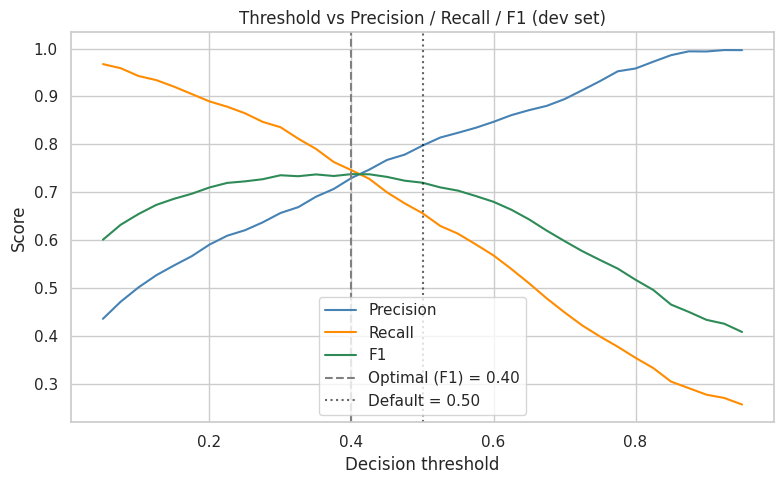

In [16]:
# --- Threshold vs metrics plot ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_df['threshold'], threshold_df['precision'], label='Precision', color='steelblue')
ax.plot(threshold_df['threshold'], threshold_df['recall'], label='Recall', color='darkorange')
ax.plot(threshold_df['threshold'], threshold_df['f1'], label='F1', color='seagreen')
ax.axvline(optimal_threshold, linestyle='--', color='grey', label=f'Optimal (F1) = {optimal_threshold:.2f}')
ax.axvline(0.5, linestyle=':', color='black', alpha=0.6, label='Default = 0.50')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold vs Precision / Recall / F1 (dev set)')
ax.legend()
plt.tight_layout()
plt.show()

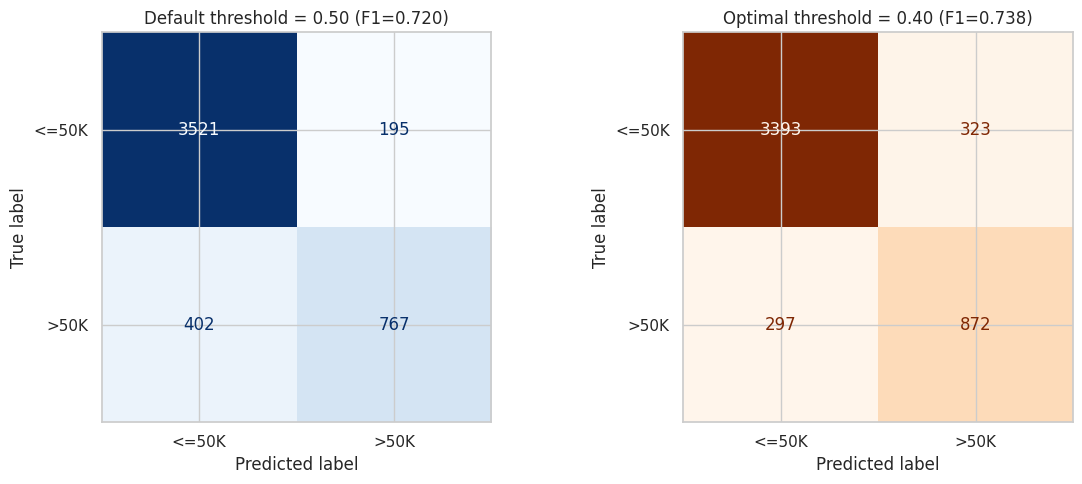

Default (0.50) — Precision: 0.7973, Recall: 0.6561, F1: 0.7198
Optimal (0.40) — Precision: 0.7297, Recall: 0.7459, F1: 0.7377


In [17]:
# --- Confusion matrices: default (0.5) vs optimal threshold, on the dev set ---
pred_default = (probs_dev_final >= 0.5).astype(int)
pred_optimal = (probs_dev_final >= optimal_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_dev, pred_default), display_labels=['<=50K', '>50K']) \
    .plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Default threshold = 0.50 (F1={f1_score(y_dev, pred_default):.3f})')
ConfusionMatrixDisplay(confusion_matrix(y_dev, pred_optimal), display_labels=['<=50K', '>50K']) \
    .plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title(f'Optimal threshold = {optimal_threshold:.2f} (F1={f1_score(y_dev, pred_optimal):.3f})')
plt.tight_layout()
plt.show()

print(f"Default (0.50) — Precision: {precision_score(y_dev, pred_default):.4f}, "
      f"Recall: {recall_score(y_dev, pred_default):.4f}, F1: {f1_score(y_dev, pred_default):.4f}")
print(f"Optimal ({optimal_threshold:.2f}) — Precision: {precision_score(y_dev, pred_optimal):.4f}, "
      f"Recall: {recall_score(y_dev, pred_optimal):.4f}, F1: {f1_score(y_dev, pred_optimal):.4f}")

## Task 5 — Final Evaluation & Save Artifact

The hold-out test set is used here for the first time since Day 1's split was created — untouched
by search, calibration fitting, or threshold selection, all of which used only `X_train`/`X_dev`.

In [18]:
probs_test = final_model.predict_proba(X_test)[:, 1]
pred_test_default = (probs_test >= 0.5).astype(int)
pred_test_optimal = (probs_test >= optimal_threshold).astype(int)

def full_metrics(y_true, y_pred, y_score):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC': roc_auc_score(y_true, y_score),
        'PR AUC': average_precision_score(y_true, y_score),
    }

final_results = pd.DataFrame([
    {'Threshold': '0.50 (default)', **full_metrics(y_test, pred_test_default, probs_test)},
    {'Threshold': f'{optimal_threshold:.2f} (tuned)', **full_metrics(y_test, pred_test_optimal, probs_test)},
]).set_index('Threshold').round(4)
final_results

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
Threshold,,,,,,
0.50 (default),0.8760,0.7930,0.6523,0.7158,0.9279,0.8302
0.40 (tuned),0.8692,0.7253,0.7297,0.7275,0.9279,0.8302


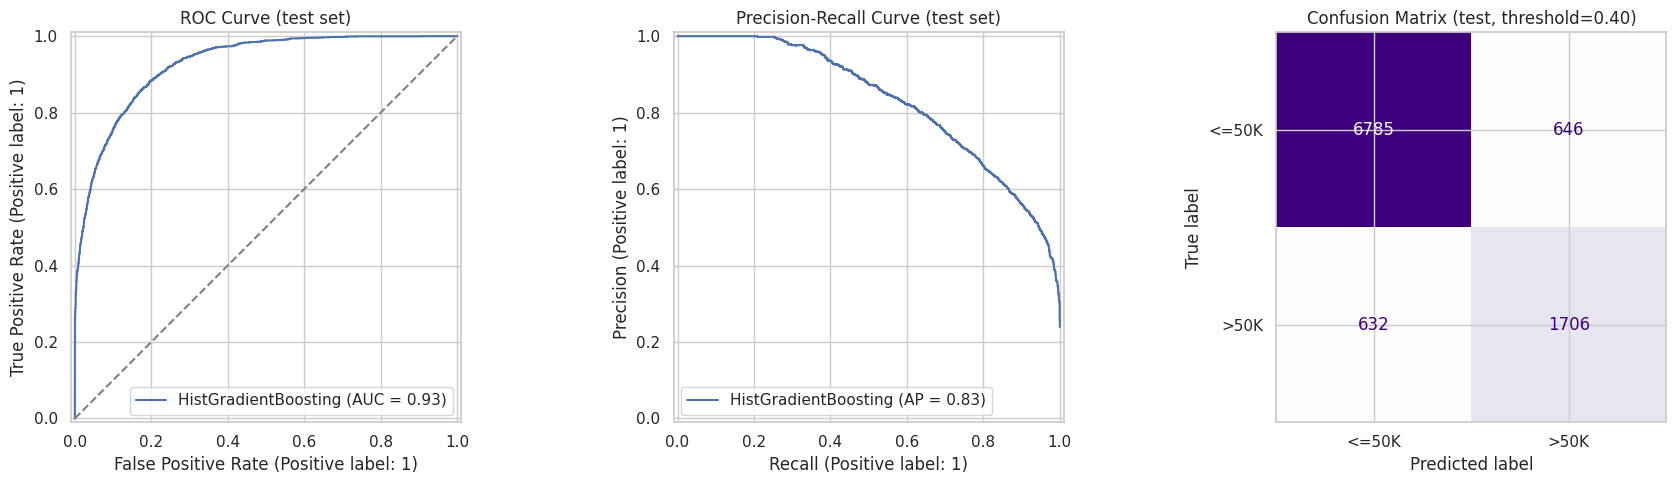

In [19]:
# --- ROC curve, PR curve, confusion matrix on the held-out test set ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, probs_test, ax=axes[0], name=best_model_name)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='grey')
axes[0].set_title('ROC Curve (test set)')

PrecisionRecallDisplay.from_predictions(y_test, probs_test, ax=axes[1], name=best_model_name)
axes[1].set_title('Precision-Recall Curve (test set)')

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_test_optimal), display_labels=['<=50K', '>50K']) \
    .plot(ax=axes[2], cmap='Purples', colorbar=False)
axes[2].set_title(f'Confusion Matrix (test, threshold={optimal_threshold:.2f})')

plt.tight_layout()
plt.show()

In [20]:
print("Day 3 CV ROC AUC (HistGradientBoosting, untuned):        0.9262 ± 0.0036")
print(f"Day 4 tuned CV ROC AUC ({best_model_name}):                 {best_search.best_score_:.4f}")
print(f"Day 4 final TEST ROC AUC ({'calibrated, ' if use_calibrated else ''}threshold={optimal_threshold:.2f}): "
      f"{roc_auc_score(y_test, probs_test):.4f}")
print("\nPerformance is stable across CV -> held-out test if the test ROC AUC sits close to the "
      "tuned CV score printed above (within roughly one CV fold's standard deviation); a much lower "
      "test score would indicate the search overfit to the CV folds themselves.")

Day 3 CV ROC AUC (HistGradientBoosting, untuned):        0.9262 ± 0.0036
Day 4 tuned CV ROC AUC (HistGradientBoosting):                 0.9253
Day 4 final TEST ROC AUC (calibrated, threshold=0.40): 0.9279

Performance is stable across CV -> held-out test if the test ROC AUC sits close to the tuned CV score printed above (within roughly one CV fold's standard deviation); a much lower test score would indicate the search overfit to the CV folds themselves.


## Save the Model

In [21]:
joblib.dump(final_model, 'final_pipeline.pkl')
print("Saved: final_pipeline.pkl")
print(f"Model: {best_model_name}"
      f"{' + CalibratedClassifierCV(sigmoid)' if use_calibrated else ' (uncalibrated, tuned)'}")
print(f"Recommended decision threshold: {optimal_threshold:.3f} (default 0.5 also usable — see metrics table above)")

Saved: final_pipeline.pkl
Model: HistGradientBoosting + CalibratedClassifierCV(sigmoid)
Recommended decision threshold: 0.400 (default 0.5 also usable — see metrics table above)


**How to infer with the saved model:**
```python
import joblib
pipeline = joblib.load('final_pipeline.pkl')
preds = pipeline.predict(X_new)               # uses threshold 0.5 internally
probs = pipeline.predict_proba(X_new)[:, 1]    # apply the tuned threshold manually if needed:
preds_tuned = (probs >= optimal_threshold).astype(int)
```
`X_new` must be a DataFrame with the same raw columns as `X_train` (the pipeline handles all
feature engineering, imputation, scaling, and encoding internally).

In [22]:
# --- Library versions for reproducibility ---
import importlib.metadata as importlib_metadata

packages = ['scikit-learn', 'pandas', 'numpy', 'scipy', 'matplotlib', 'seaborn', 'joblib']
print("Library versions:")
for pkg in packages:
    try:
        print(f"  {pkg}: {importlib_metadata.version(pkg)}")
    except importlib_metadata.PackageNotFoundError:
        print(f"  {pkg}: not found")

Library versions:
  scikit-learn: 1.8.0
  pandas: 3.0.2
  numpy: 2.4.4
  scipy: 1.17.1
  matplotlib: 3.10.8
  seaborn: 0.13.2
  joblib: 1.5.3
